In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/sample_labels.csv
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00006199_010.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00003503_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00017423_004.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00022830_001.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00016794_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00010790_035.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00015606_039.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00005448_001.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00025094_000.png
/kaggle/input/data

In [10]:
import os

print("Aapke Kaggle folder mein mojood CSV files yeh hain:\n")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'): # Sirf CSV files dhoondega
            print(os.path.join(dirname, filename))

Aapke Kaggle folder mein mojood CSV files yeh hain:

/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/sample_labels.csv


In [11]:
import pandas as pd

# Apni CSV file ka naam ya Kaggle path yahan likhein
file_path = '/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv' 

# CSV ko read kar ke ek DataFrame (table) mein la rahe hain
df = pd.read_csv(file_path)
print("Original Data ki shape:", df.shape)
print(df.head())

Original Data ki shape: (5606, 11)
        Image Index                                     Finding Labels  \
0  00000013_005.png  Emphysema|Infiltration|Pleural_Thickening|Pneu...   
1  00000013_026.png                             Cardiomegaly|Emphysema   
2  00000017_001.png                                         No Finding   
3  00000030_001.png                                        Atelectasis   
4  00000032_001.png                        Cardiomegaly|Edema|Effusion   

   Follow-up #  Patient ID Patient Age Patient Gender View Position  \
0            5          13        060Y              M            AP   
1           26          13        057Y              M            AP   
2            1          17        077Y              M            AP   
3            1          30        079Y              M            PA   
4            1          32        055Y              F            AP   

   OriginalImageWidth  OriginalImageHeight  OriginalImagePixelSpacing_x  \
0                3

Preprocessing start ho rahi hai...
Data clean ho gaya! Clean data ki shape: (5606, 11)
Data Warehouse tayyar hai aur data load ho gaya!

Database se Top 10 bimariyon ka data access kar rahe hain:

          Finding_Labels  total_images
0             No Finding          3044
1           Infiltration           503
2               Effusion           203
3            Atelectasis           192
4                 Nodule           144
5           Pneumothorax           114
6                   Mass            99
7          Consolidation            72
8  Effusion|Infiltration            69
9     Pleural_Thickening            65


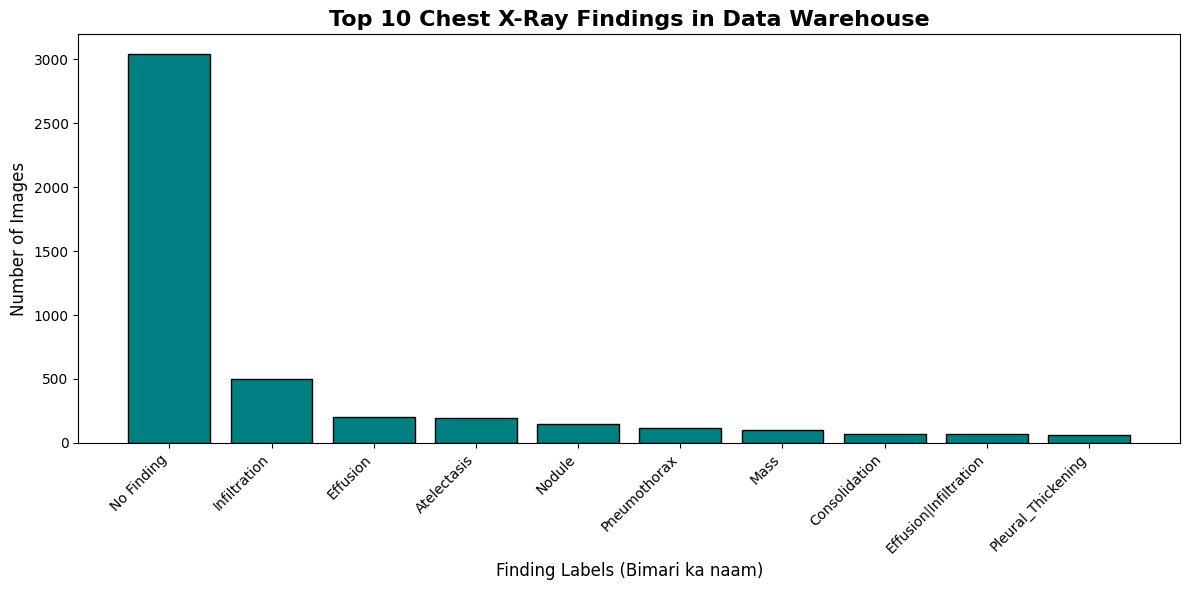

In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# ==========================================
# STEP 2: PREPROCESS THE CSV DATA
# ==========================================
print("Preprocessing start ho rahi hai...")
# 1. Missing values aur duplicate rows ko khatam karein
df_clean = df.dropna().drop_duplicates()

# 2. Database mein column names ke darmiyan "Space" masla karti hai 
# Isliye hum sab columns ke naam mein space ki jagah '_' laga rahe hain
# (Jaise 'Finding Labels' ban jayega 'Finding_Labels')
df_clean.columns = df_clean.columns.str.replace(' ', '_')
print("Data clean ho gaya! Clean data ki shape:", df_clean.shape)

# ==========================================
# STEP 3: CREATE A SMALL DATA WAREHOUSE/DATABASE
# ==========================================
# Ek SQLite database file banayen aur data ko 'xray_data' table mein daal dein
conn = sqlite3.connect('xray_warehouse.db')
df_clean.to_sql('xray_data', conn, if_exists='replace', index=False)
print("Data Warehouse tayyar hai aur data load ho gaya!\n")

# ==========================================
# STEP 4: ALLOW USERS TO ACCESS THE DATA
# ==========================================
print("Database se Top 10 bimariyon ka data access kar rahe hain:\n")
# SQL Query: Check karte hain ke konsi bimari ki kitni tasveerein hain
query = """
SELECT Finding_Labels, COUNT(*) as total_images 
FROM xray_data 
GROUP BY Finding_Labels 
ORDER BY total_images DESC
LIMIT 10
"""
user_result = pd.read_sql_query(query, conn)
print(user_result)

# ==========================================
# STEP 5: DISPLAY RESULTS IN GRAPH FORM
# ==========================================
# Bar chart banayen
plt.figure(figsize=(12, 6))
plt.bar(user_result['Finding_Labels'], user_result['total_images'], color='teal', edgecolor='black')

# Graph ko pyara aur parhne ke qabil banayen
plt.title('Top 10 Chest X-Ray Findings in Data Warehouse', fontsize=16, fontweight='bold')
plt.xlabel('Finding Labels (Bimari ka naam)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# X-axis ke labels ko terha (rotate) karein taake mix na hon
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Graph show karein
plt.show()

# Aakhir mein database connection band kar dein
conn.close()